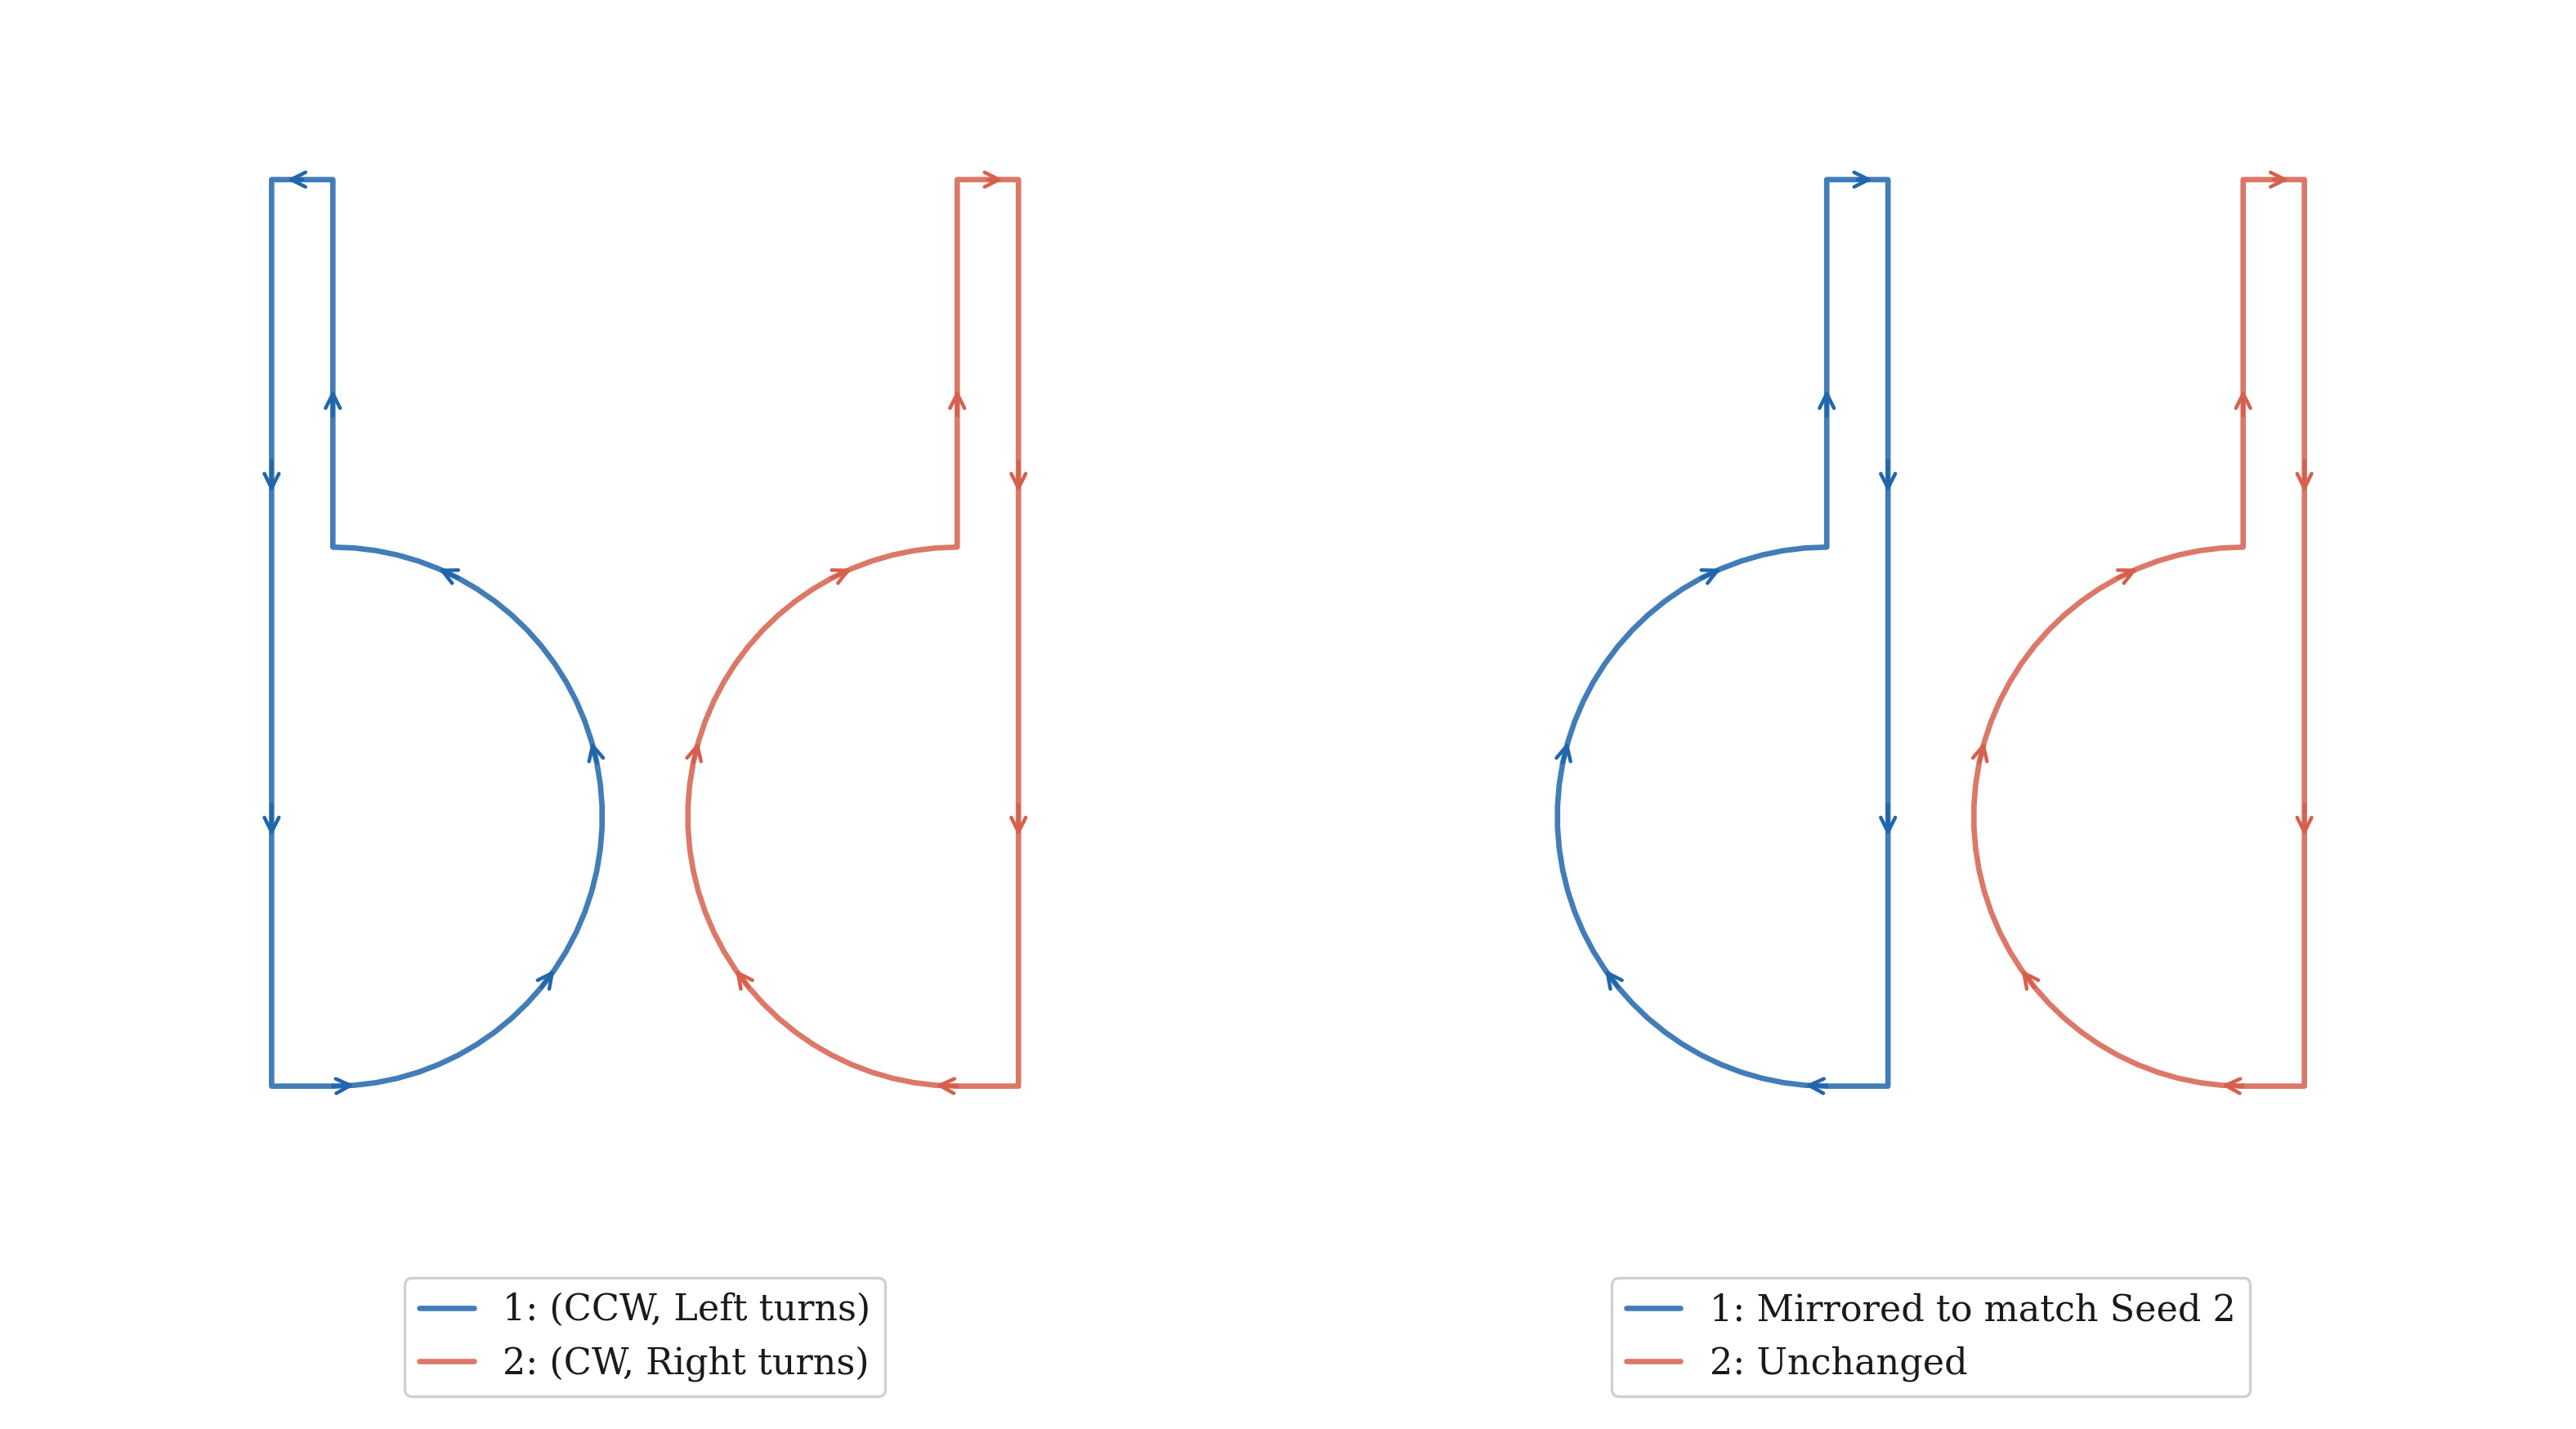

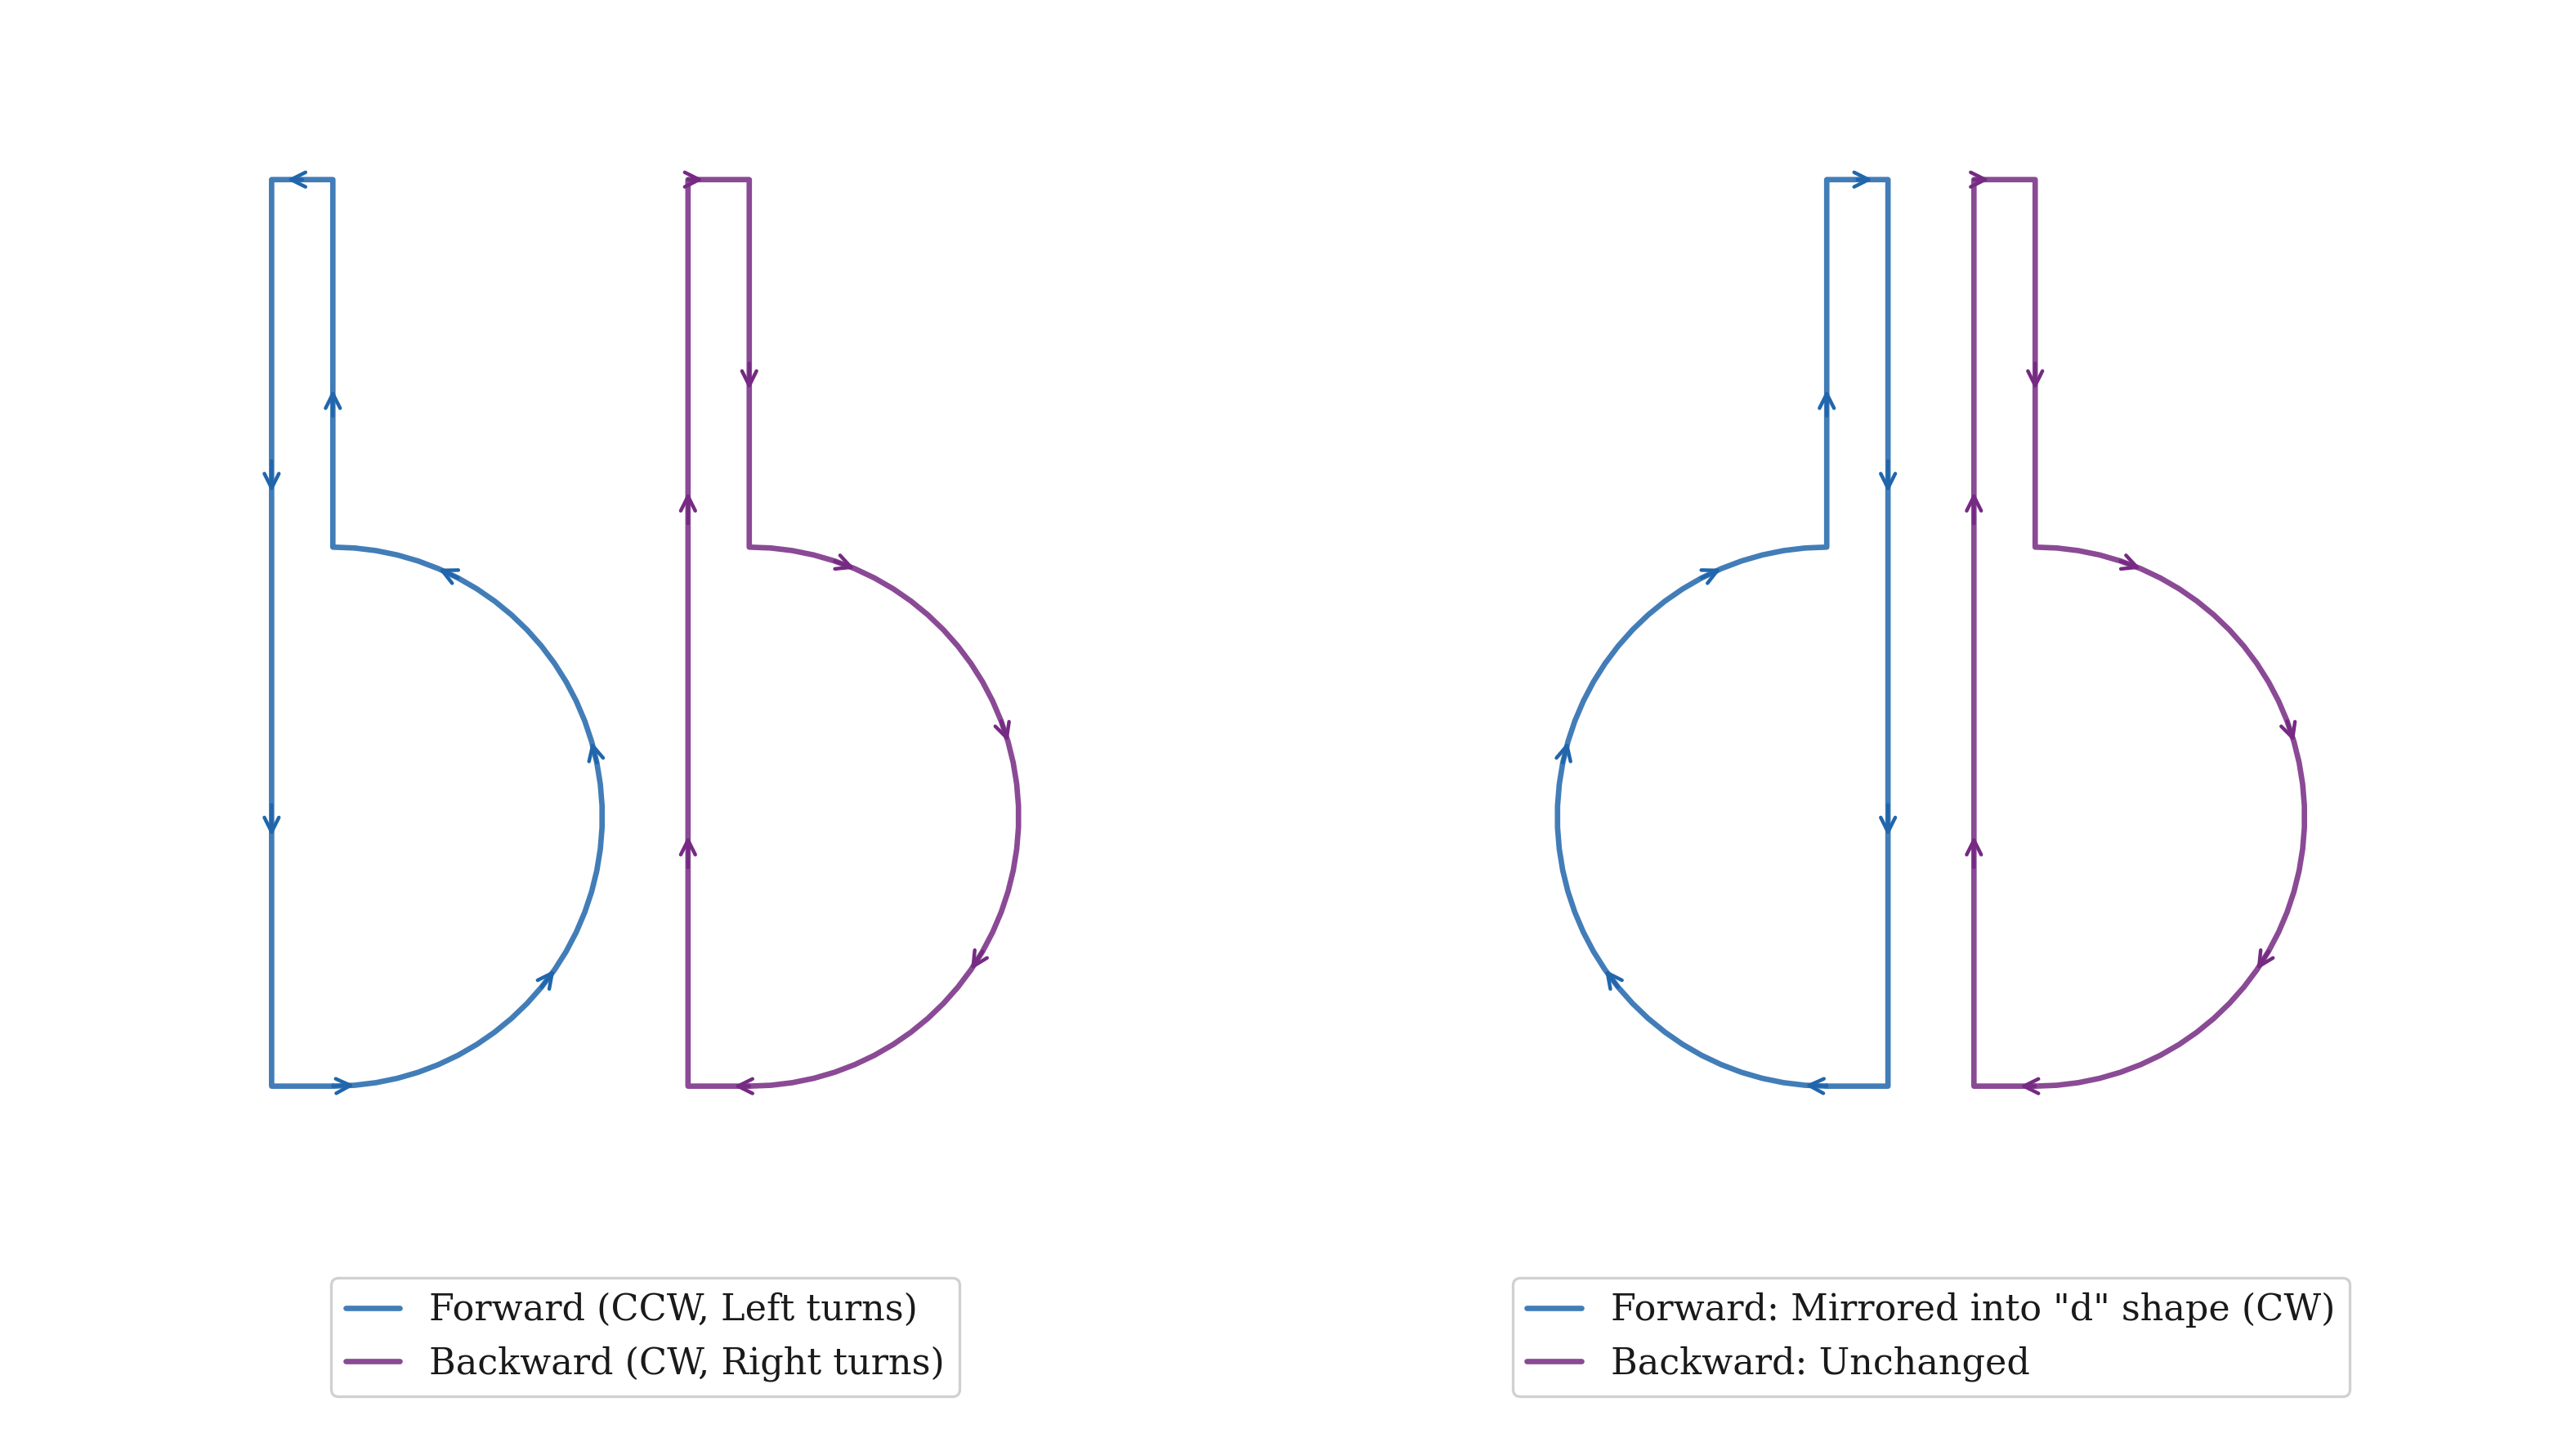

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 9,
    'legend.fontsize': 8,
    'figure.dpi': 400,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'text.color': '#1a1a1a',
})

COLOR_A = '#2166ac'
COLOR_B = '#d6604d'
COLOR_D = '#762a83'

def signed_area(x, y):
    return 0.5 * np.sum(x[:-1] * y[1:] - x[1:] * y[:-1])

def canonicalize_geometry(x, y):
    # CHANGED: If the track is Counter-Clockwise (mostly Left turns), 
    # mirror it to CW (mostly Right turns)
    if signed_area(x, y) > 0:
        cx = (np.min(x) + np.max(x)) / 2
        return 2 * cx - x, y
    return x, y

def add_directional_arrows(ax, x, y, color, label, lw=1.2, alpha=0.85):
    ax.plot(x, y, color=color, linewidth=lw, label=label, alpha=alpha, solid_capstyle='round')
    step = max(len(x) // 8, 1)
    for i in range(0, len(x) - step, step):
        ax.annotate('', xy=(x[i+1], y[i+1]), xytext=(x[i], y[i]),
                    arrowprops=dict(arrowstyle='->', color=color, lw=0.8,
                                   shrinkA=0, shrinkB=0, mutation_scale=8))

# --- lowercase 'b' shape generation ---
bowl_r  = 1.1    
stem_top = 2.6   
stem_w = 0.25    

t = np.linspace(-np.pi/2, np.pi/2, 40)
x_arc, y_arc = bowl_r * np.cos(t), bowl_r * np.sin(t)

y_stem_up = np.linspace(bowl_r, stem_top, 15)[1:]
x_stem_up = np.zeros_like(y_stem_up)

x_stem_top = np.linspace(0, -stem_w, 5)[1:]
y_stem_top = np.full_like(x_stem_top, stem_top)

y_stem_down = np.linspace(stem_top, -bowl_r, 30)[1:]
x_stem_down = np.full_like(y_stem_down, -stem_w)

x_stem_bot = np.linspace(-stem_w, 0, 5)[1:]
y_stem_bot = np.full_like(x_stem_bot, -bowl_r)

x_b = np.concatenate([x_arc, x_stem_up, x_stem_top, x_stem_down, x_stem_bot])
y_b = np.concatenate([y_arc, y_stem_up, y_stem_top, y_stem_down, y_stem_bot])

# Center the track on X=0
x_b -= (np.min(x_b) + np.max(x_b)) / 2

# Variations
x_d, y_d = -x_b, y_b
x_b_cw, y_b_cw = x_b[::-1], y_b[::-1]

OFFSET = 0.85   

# --- Formatting Helper ---
def format_axes(axs):
    for ax in axs:
        ax.set_aspect('equal')
        ax.axis('off')
        
        # HARDCODED LIMITS
        ax.set_xlim(-2.5, 2.5)
        ax.set_ylim(-1.5, 3.2)
        
        # Fixed legend position
        leg = ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), 
                        frameon=True, framealpha=0.9, edgecolor='#cccccc', handlelength=1.5)
        leg.get_frame().set_linewidth(0.6)


# =======================================================================
# FIGURE 1: Eliminating Mirrored Duplicates
# =======================================================================
fig1, axs1 = plt.subplots(1, 2, figsize=(8.0, 5.0))

# Input
add_directional_arrows(axs1[0], x_b - OFFSET, y_b, COLOR_A, '1: (CCW, Left turns)')
add_directional_arrows(axs1[0], x_d + OFFSET, y_d, COLOR_B, '2: (CW, Right turns)')

# Output
x1c, y1c = canonicalize_geometry(x_b, y_b)
x2c, y2c = canonicalize_geometry(x_d, y_d)

# CHANGED ANNOTATIONS: Seed 1 is now the one that gets mirrored, Seed 2 stays unchanged.
add_directional_arrows(axs1[1], x1c - OFFSET, y1c, COLOR_A, '1: Mirrored to match Seed 2')
add_directional_arrows(axs1[1], x2c + OFFSET, y2c, COLOR_B, '2: Unchanged')

format_axes(axs1)

# Fixed layout margins
fig1.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.2, wspace=0.05)

# Save image exactly as built
fig1.savefig('winding 1.png', dpi=400, bbox_inches=None)


# =======================================================================
# FIGURE 2: Preserving Forward/Backward Tracks
# =======================================================================
fig2, axs2 = plt.subplots(1, 2, figsize=(8.0, 5.0))

# Input
add_directional_arrows(axs2[0], x_b - OFFSET, y_b, COLOR_A, 'Forward (CCW, Left turns)')
add_directional_arrows(axs2[0], x_b_cw + OFFSET, y_b_cw, COLOR_D, 'Backward (CW, Right turns)')

# Output
x3c, y3c = canonicalize_geometry(x_b, y_b)
x4c, y4c = canonicalize_geometry(x_b_cw, y_b_cw)

# CHANGED ANNOTATIONS: Forward gets mirrored into the "d" family, Backward stays unchanged.
add_directional_arrows(axs2[1], x3c - OFFSET, y3c, COLOR_A, 'Forward: Mirrored into "d" shape (CW)')
add_directional_arrows(axs2[1], x4c + OFFSET, y4c, COLOR_D, 'Backward: Unchanged')

format_axes(axs2)

# Apply exact same layout margins as Figure 1
fig2.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.2, wspace=0.05)

# Save image exactly as built
fig2.savefig('winding 2.png', dpi=400, bbox_inches=None)

# Show the UI just in case you want to view them interactively 
plt.show()